In [ ]:
#################### The code was written for the analysis in Vertex AI by Google LLC ####################

### Install Vertex AI SDK for Gen AI Evaluation Service

In [ ]:
%pip install -U -q google-cloud-aiplatform[evaluation]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 26.2 MB/s eta 0:00:00


### Install other required packages

In [ ]:
%pip install -U -q datasets
# %pip install -U -q anthropic[vertex]
# %pip install -U -q openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.2 MB/s eta 0:00:00


### Restart runtime
To use the newly installed packages in this Jupyter runtime, you must restart the runtime. You can do this by running the cell below, which restarts the current kernel.

The restart might take a minute or longer. After it's restarted, continue to the next step.

In [ ]:
# import IPython

# app = IPython.Application.instance()
# app.kernel.do_shutdown(True)

<div class="alert alert-block alert-warning">
<b>⚠️ The kernel is going to restart. Wait until it's finished before continuing to the next step. ⚠️</b>
</div>


### Authenticate your notebook environment (Colab only)

In [ ]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Set Google Cloud project information and initialize Vertex AI SDK

In [ ]:
PROJECT_ID = "som-nero-phi-tof-painard"  # @param {type:"string"}
LOCATION = "us-central1"  # @param {type:"string"}

if not PROJECT_ID or not PROJECT_ID == "som-nero-phi-tof-painard":
    raise ValueError("Please set your PROJECT_ID")


import vertexai

vertexai.init(project=PROJECT_ID, location=LOCATION)

### Import libraries

In [ ]:
from google.auth import default, transport
import openai
from vertexai.evaluation import (
    EvalTask,
    MetricPromptTemplateExamples,
    PairwiseMetric,
    PointwiseMetric,
    PointwiseMetricPromptTemplate,
)
from vertexai.generative_models import GenerativeModel

### Library settings

In [ ]:
# @title

import logging
import warnings

import pandas as pd

logging.getLogger("urllib3.connectionpool").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# pd.set_option('display.max_colwidth', None)

### Helper functions

## Load an evaluation dataset

In [ ]:
from google.cloud import storage

# Configure your GCS bucket and file
bucket_name = "yw-pain"
file_path = "data/"

In [ ]:
from vertexai import init
from vertexai.generative_models import GenerativeModel


# Initialize Vertex AI
PROJECT_ID = "som-nero-phi-tof-painard"  # Replace with your Google Cloud project ID
LOCATION = "us-central1"  # Adjust based on your model location (e.g., "europe-west4")

init(project=PROJECT_ID, location=LOCATION)



### Define a model

In [ ]:
# Model to be evaluated
# MODEL_ID="gemini-2.0-flash-lite-001"
MODEL_ID = "gemini-2.5-flash"
# model = GenerativeModel(
#     MODEL_ID,
#     generation_config={"temperature": 0.6, "max_output_tokens": 100, "top_k": 1},
# )
#Print available methods
# print(dir(model))

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

import re
import string
import os
from tqdm import tqdm
import math
from transformers.generation.logits_process import LogitsProcessor

import torch._dynamo
torch._dynamo.config.suppress_errors = True
import torch
torch.cuda.empty_cache()

from prompts_reason import get_prompts

import gc
import gcsfs
fs = gcsfs.GCSFileSystem()

def extract_prediction_from_json(response):
    """Extract the prediction number from JSON response."""
    try:
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            json_str = match.group(0)
            data = json.loads(json_str)

            if "classification" in data:
                print(
                    f"*****debug**** matched classification in JSON: "
                    f"{data['classification']}"
                )
                return int(data["classification"])

    except Exception as e:
        print(f"Error parsing JSON: {e}")

    # Fallback 1
    match = re.search(r'classification"?\s*[=:]\s*([1-5])', response)
    if match:
        print(
            f"*****debug**** matched classification pattern: "
            f"{match.group(1)}"
        )
        return int(match.group(1))

    # Fallback 2
    print("*****debug**** trying to match simple number pattern")
    match = re.search(r"([1-5])", response)

    if match:
        print(
            f"*****debug**** matched simple number pattern: "
            f"{match.group(1)}"
        )
        return int(match.group(1))

    print(
        f"Warning: Could not extract prediction from response: "
        f"{response[:100]}..."
    )
    return 0


class SanitizeLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        scores = torch.nan_to_num(
            scores,
            nan=-1e9,
            posinf=1e9,
            neginf=-1e9,
        )
        return scores.clamp(min=-1e9, max=1e9)


class MinimalSanitizeLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        scores = scores.clone()
        scores[scores != scores] = -1e9
        scores[scores == float("inf")] = 1e9
        scores[scores == float("-inf")] = -1e9
        scores = scores.clamp(min=-100, max=100)
        return scores


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def temp_to_str(temp):
    """
    Ensure temperature is represented exactly the same way everywhere.

    Examples:
        0   -> "0"
        0.3 -> "0.3"
        1.0 -> "1.0"
    """
    if isinstance(temp, int):
        return str(temp)

    if isinstance(temp, float):
        if temp == 0:
            return "0"
        if temp == 1.0:
            return "1.0"

    return str(temp)


def get_prediction_paths(base_dir, strat_name, temp):
    """
    Return the exact CSV and JSON prediction paths for one
    (strategy, temperature) combination.
    """
    temp_str = temp_to_str(temp)

    csv_path = (
        f"{base_dir}/prediction/"
        f"{strat_name}_temp{temp_str}_predictions.csv"
    )

    json_path = (
        f"{base_dir}/prediction/"
        f"{strat_name}_temp{temp_str}_predictions.json"
    )

    return csv_path, json_path


def gcs_exists(path):
    """Check whether a GCS file exists."""
    return fs.exists(path)


def prediction_file_is_complete(csv_path, expected_n):
    """
    Check whether an existing prediction CSV appears complete.

    A run counts as complete only if:
      1. the exact file exists;
      2. it can be read;
      3. it contains y_true and y_pred;
      4. it contains exactly expected_n rows.
    """
    if not gcs_exists(csv_path):
        return False

    try:
        df = pd.read_csv(csv_path)

        required_cols = {"y_true", "y_pred"}

        if not required_cols.issubset(df.columns):
            print(
                f"Existing file has missing columns and will be rerun:\n"
                f"  {csv_path}"
            )
            return False

        if len(df) != expected_n:
            print(
                f"Existing file has {len(df)} rows, expected {expected_n}. "
                f"Will rerun:\n  {csv_path}"
            )
            return False

        if df["y_true"].isna().any() or df["y_pred"].isna().any():
            print(
                f"Existing file contains missing predictions. Will rerun:\n"
                f"  {csv_path}"
            )
            return False

        return True

    except Exception as e:
        print(
            f"Could not validate existing prediction file:\n"
            f"  {csv_path}\n"
            f"Error: {e}\n"
            f"Will rerun this combination."
        )
        return False


def save_json_to_gcs(data, path):
    """Save JSON directly to GCS."""
    with fs.open(path, "w") as f:
        json.dump(data, f, indent=2)


def calculate_metrics_from_prediction_file(csv_path):
    """
    Load an existing prediction CSV and calculate metrics.

    This is used for BOTH old and newly generated runs, ensuring that
    summary tables and plots are rebuilt from disk rather than relying
    on only the current Python session.
    """
    pred_df = pd.read_csv(csv_path)

    y_true = pred_df["y_true"].astype(int).tolist()
    y_pred = pred_df["y_pred"].astype(int).tolist()

    acc = accuracy_score(y_true, y_pred)

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    prec = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[1, 2, 3, 4],
    )

    return {
        "accuracy": acc,
        "f1_macro": f1,
        "recall": recall,
        "precision": prec,
        "confusion_matrix": cm,
        "true_labels": y_true,
        "predicted_labels": y_pred,
    }


# ---------------------------------------------------------------------
# Inference
# ---------------------------------------------------------------------

def batched_inference(
    data,
    model,
    prompt_fn,
    temp,
    batch_size=8,
    model_id="model",
):
    y_true = []
    y_pred = []
    responses = []
    json_data = []

    total = len(data)
    n_batches = math.ceil(total / batch_size)

    for i in tqdm(
        range(n_batches),
        desc=f"Running batches (temp={temp})",
    ):
        batch = data.iloc[
            i * batch_size:(i + 1) * batch_size
        ]

        texts = batch["text"].tolist()
        prompts = [prompt_fn(t) for t in texts]

        for j, (_, row) in enumerate(batch.iterrows()):

            # IMPORTANT:
            # Send only the prompt corresponding to this row.
            response = model.generate_content(prompts[j])

            response_text = response.text

            pred = extract_prediction_from_json(response_text)

            true_label = int(row["label"])

            y_true.append(true_label)
            y_pred.append(pred)
            responses.append(response_text)

            json_data.append({
                "snippet": texts[j],
                "true_label": true_label,
                "predicted_label": pred,
                "full_response": response_text,
            })

    return y_true, y_pred, responses, json_data


# ---------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------

def compare_temperatures_with_json(model_id, data):
    """
    Compare prompt strategies and temperatures.

    Behavior:
    ---------
    1. Check every exact (strategy, temperature) prediction file.
    2. Identify missing/incomplete runs BEFORE loading any model.
    3. Run only missing/incomplete combinations.
    4. Load ALL prediction files from disk.
    5. Recalculate metrics from old + new predictions.
    6. Rebuild confusion matrices.
    7. Rebuild summary CSV.
    8. Rebuild temperature comparison plots.
    """

    print("=" * 80)
    print("Running temperature / prompt-strategy comparison")
    print("=" * 80)

    strategies = get_prompts()

    temperatures = [
        0,
        0.3,
        0.5,
        0.7,
        1.0,
    ]

    base_dir = (
        f"gs://{bucket_name}/output/"
        f"reason_prompting_test/{model_id}"
    )

    prediction_dir = f"{base_dir}/prediction"
    figure_dir = f"{base_dir}/figures"

    # GCS directories do not technically need to be created.
    # gcsfs/pandas will create objects directly at these paths.

    expected_n = len(data)

    # ================================================================
    # STEP 1:
    # Check EVERY exact strategy x temperature prediction file
    # BEFORE creating any model.
    # ================================================================

    missing_runs = []

    print("\nChecking existing prediction files...\n")

    for strat_name in strategies.keys():

        for temp in temperatures:

            csv_path, json_path = get_prediction_paths(
                base_dir,
                strat_name,
                temp,
            )

            complete = prediction_file_is_complete(
                csv_path,
                expected_n,
            )

            if complete:
                print(
                    f"[COMPLETE] "
                    f"strategy={strat_name}, temp={temp}"
                )

            else:
                print(
                    f"[MISSING]  "
                    f"strategy={strat_name}, temp={temp}"
                )

                missing_runs.append({
                    "strategy": strat_name,
                    "temperature": temp,
                    "csv_path": csv_path,
                    "json_path": json_path,
                })

    total_combinations = (
        len(strategies) * len(temperatures)
    )

    print("\n" + "=" * 80)
    print(
        f"Complete: "
        f"{total_combinations - len(missing_runs)} / "
        f"{total_combinations}"
    )
    print(
        f"Need to run: "
        f"{len(missing_runs)} / "
        f"{total_combinations}"
    )
    print("=" * 80)

    # ================================================================
    # STEP 2:
    # Only initialize models if at least one run is missing.
    # ================================================================

    if len(missing_runs) == 0:

        print(
            "\nAll exact (prompt strategy, temperature) "
            "prediction files are already complete."
        )

        print(
            "Skipping model initialization and inference."
        )

    else:

        print(
            f"\nRunning {len(missing_runs)} missing/incomplete "
            f"combination(s)..."
        )

        for run_idx, run in enumerate(
            missing_runs,
            start=1,
        ):

            strat_name = run["strategy"]
            temp = run["temperature"]
            csv_path = run["csv_path"]
            json_path = run["json_path"]

            prompt_fn = strategies[strat_name]

            print("\n" + "=" * 80)
            print(
                f"Run {run_idx}/{len(missing_runs)}"
            )
            print(f"Strategy:    {strat_name}")
            print(f"Temperature: {temp}")
            print("=" * 80)

            # --------------------------------------------------------
            # Model is initialized ONLY for a run that actually needs it
            # --------------------------------------------------------

            model = GenerativeModel(
                model_id,
                generation_config={
                    "temperature": temp,
                    "max_output_tokens": 1024,
                    "top_k": 1,
                },
            )

            try:

                y_true, y_pred, responses, json_data = (
                    batched_inference(
                        data=data,
                        model=model,
                        prompt_fn=prompt_fn,
                        temp=temp,
                        batch_size=8,
                        model_id=model_id,
                    )
                )

                # ----------------------------------------------------
                # Save CSV first
                # ----------------------------------------------------

                pred_df = pd.DataFrame({
                    "y_true": y_true,
                    "y_pred": y_pred,
                })

                pred_df.to_csv(
                    csv_path,
                    index=False,
                )

                # ----------------------------------------------------
                # Save full JSON
                # ----------------------------------------------------

                save_json_to_gcs(
                    json_data,
                    json_path,
                )

                print(
                    f"\nSaved predictions:\n"
                    f"  {csv_path}"
                )

            finally:
                # Release model before proceeding to next combination
                del model

                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    # ================================================================
    # STEP 3:
    # Rebuild EVERYTHING from prediction files on disk.
    #
    # This means:
    #   - old runs are included
    #   - newly completed runs are included
    #   - current Python-memory state does not matter
    # ================================================================

    print("\n" + "=" * 80)
    print("Rebuilding results from prediction files")
    print("=" * 80)

    results_by_strategy = {}
    summary_rows = []

    for strat_name in strategies.keys():

        results_by_strategy[strat_name] = {}

        for temp in temperatures:

            csv_path, _ = get_prediction_paths(
                base_dir,
                strat_name,
                temp,
            )

            # Safety check
            if not prediction_file_is_complete(
                csv_path,
                expected_n,
            ):
                print(
                    f"WARNING: Cannot include incomplete run: "
                    f"{strat_name}, temp={temp}"
                )
                continue

            # --------------------------------------------------------
            # Load predictions from disk and recalculate metrics
            # --------------------------------------------------------

            results = calculate_metrics_from_prediction_file(
                csv_path
            )

            results_by_strategy[strat_name][temp] = results

            summary_rows.append({
                "strategy": strat_name,
                "temperature": temp,
                "accuracy": results["accuracy"],
                "f1_macro": results["f1_macro"],
                "recall": results["recall"],
                "precision": results["precision"],
            })

            print(
                f"\n{strat_name}, temp={temp}"
            )
            print(
                f"  Accuracy:  "
                f"{results['accuracy']:.4f}"
            )
            print(
                f"  F1 macro:  "
                f"{results['f1_macro']:.4f}"
            )
            print(
                f"  Precision: "
                f"{results['precision']:.4f}"
            )
            print(
                f"  Recall:    "
                f"{results['recall']:.4f}"
            )

            # ========================================================
            # Rebuild confusion matrix
            # ========================================================

            cm = results["confusion_matrix"]

            plt.figure(figsize=(8, 6))

            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=[1, 2, 3, 4],
                yticklabels=[1, 2, 3, 4],
            )

            plt.xlabel("Predicted Label")
            plt.ylabel("True Label")

            plt.title(
                f"Confusion Matrix - "
                f"{strat_name} (Temp={temp})"
            )

            cm_path = (
                f"{figure_dir}/"
                f"cm_{strat_name}_temp"
                f"{temp_to_str(temp)}.png"
            )

            # plt.savefig(
            #     cm_path,
            #     bbox_inches="tight",
            # )

            plt.close()

    # ================================================================
    # STEP 4:
    # Rebuild summary dataframe
    # ================================================================

    summary_df = pd.DataFrame(summary_rows)

    if len(summary_df) > 0:

        summary_df = summary_df.sort_values(
            ["strategy", "temperature"]
        ).reset_index(drop=True)

    summary_path = (
        f"{prediction_dir}/"
        f"temperature_strategy_comparison.csv"
    )

    summary_df.to_csv(
        summary_path,
        index=False,
    )

    print(
        f"\nSaved rebuilt summary:\n"
        f"  {summary_path}"
    )

    # ================================================================
    # STEP 5:
    # Rebuild temperature comparison figures
    # ================================================================

    metrics = [
        "accuracy",
        "f1_macro",
        "recall",
        "precision",
    ]

    for metric in metrics:

        plt.figure(figsize=(12, 8))

        plotted_anything = False

        for strat_name in strategies.keys():

            temps_available = []
            values = []

            for temp in temperatures:

                if (
                    strat_name in results_by_strategy
                    and temp in results_by_strategy[strat_name]
                ):

                    temps_available.append(temp)

                    values.append(
                        results_by_strategy[
                            strat_name
                        ][temp][metric]
                    )

            # Allows plotting even if some combinations remain missing
            if len(values) > 0:

                plt.plot(
                    temps_available,
                    values,
                    marker="o",
                    linewidth=2,
                    label=strat_name,
                )

                plotted_anything = True

        if plotted_anything:

            plt.xlabel("Temperature")
            plt.ylabel(metric.replace("_", " ").title())

            plt.title(
                f"Effect of Temperature on "
                f"{metric.replace('_', ' ').title()} "
                f"by Strategy"
            )

            plt.legend()

            plt.grid(
                True,
                linestyle="--",
                alpha=0.7,
            )

            plot_path = (
                f"{figure_dir}/"
                f"temperature_effect_{metric}.png"
            )

            plt.savefig(
                plot_path,
                bbox_inches="tight",
            )

        plt.close()

    print("\n" + "=" * 80)
    print("Finished rebuilding summaries and plots.")
    print("=" * 80)

    return summary_df


Index(['text', 'label'], dtype='object')
Running temperature / prompt-strategy comparison

Checking existing prediction files...

[COMPLETE] strategy=chain_of_thought, temp=0
[COMPLETE] strategy=chain_of_thought, temp=0.3
[COMPLETE] strategy=chain_of_thought, temp=0.5
[COMPLETE] strategy=chain_of_thought, temp=0.7
[COMPLETE] strategy=chain_of_thought, temp=1.0
[COMPLETE] strategy=one_shot, temp=0
[COMPLETE] strategy=one_shot, temp=0.3
[COMPLETE] strategy=one_shot, temp=0.5
[COMPLETE] strategy=one_shot, temp=0.7
[COMPLETE] strategy=one_shot, temp=1.0
[COMPLETE] strategy=two_shot, temp=0
[COMPLETE] strategy=two_shot, temp=0.3
[COMPLETE] strategy=two_shot, temp=0.5
[COMPLETE] strategy=two_shot, temp=0.7
[COMPLETE] strategy=two_shot, temp=1.0
[COMPLETE] strategy=structured_reasoning, temp=0
[COMPLETE] strategy=structured_reasoning, temp=0.3
[COMPLETE] strategy=structured_reasoning, temp=0.5
[MISSING]  strategy=structured_reasoning, temp=0.7
[MISSING]  strategy=structured_reasoning, temp=1.

Running batches (temp=0.7):   0%|          | 0/8 [00:00<?, ?it/s]

*****debug**** trying to match simple number pattern
*****debug**** matched simple number pattern: 1
*****debug**** trying to match simple number pattern
*****debug**** matched simple number pattern: 1
*****debug**** matched classification in JSON: 1
*****debug**** matched classification in JSON: 1
*****debug**** trying to match simple number pattern
*****debug**** matched simple number pattern: 1
*****debug**** trying to match simple number pattern
*****debug**** matched simple number pattern: 1
*****debug**** matched classification in JSON: 2


Running batches (temp=0.7):  12%|█▎        | 1/8 [00:37<04:22, 37.47s/it]

*****debug**** matched classification in JSON: 1
*****debug**** matched classification in JSON: 1
*****debug**** trying to match simple number pattern
*****debug**** matched simple number pattern: 1
*****debug**** matched classification in JSON: 2
*****debug**** matched classification in JSON: 2
*****debug**** matched classification in JSON: 2
*****debug**** matched classification in JSON: 3
*****debug**** matched classification in JSON: 2


...

*****debug**** matched classification in JSON: 5
*****debug**** trying to match simple number pattern
- Cannabis use mentioned: Yes, "marijuana #### #### dependence" is mentioned as part of th...
*****debug**** matched classification in JSON: 5
*****debug**** matched classification in JSON: 1


Running batches (temp=1.0): 100%|██████████| 8/8 [04:27<00:00, 33.48s/it]

*****debug**** matched classification in JSON: 5



Saved predictions:
  gs://yw-pain/output/reason_prompting_test/gemini-2.5-flash/prediction/uncertainty_handling_temp1.0_predictions.csv

Rebuilding results from prediction files

chain_of_thought, temp=0
  Accuracy:  0.3333
  F1 macro:  0.2370
  Precision: 0.2262
  Recall:    0.2857


FileNotFoundError: [Errno 2] No such file or directory: 'gs://yw-pain/output/reason_prompting_test/gemini-2.5-flash/figures/cm_chain_of_thought_temp0.png'

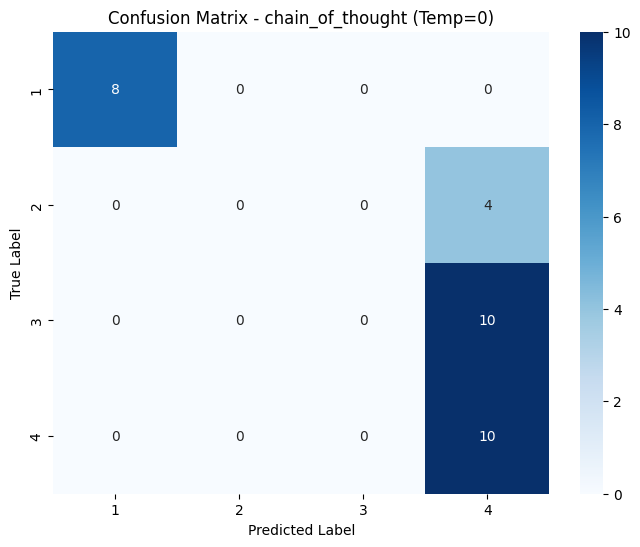

In [ ]:
# Run the temperature comparison with JSON format
# Load data
data = pd.read_csv(f"gs://{bucket_name}/data/set-validation_task-reason_label-6_sample-10_desc-stratified.csv")
# only keep the "Snippets" and "Label" columns
data = data[["Snippets", "Label"]]
data = data.rename(columns={"Snippets": "text", "Label": "label"})
print(data.columns)
summary = compare_temperatures_with_json(MODEL_ID, data)
print("\nSummary of results across temperatures:")
print(summary)